In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.knn import KNN
from utils.metrics_evaluator import MetricsEvaluator
from utils.helpers import bulk_min_max_normalization, to_percent, missing_value_insight, plot_distribution, fill_missing_values

In [2]:
def drawHistogram(df: pd.DataFrame, col: str):
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribusi Data {col}')
    plt.show()

In [3]:
columns = {
    'age': 'umur', 
    'gender': 'jenis_kelamin', 
    'systolic_bp': 'sistolik', 
    'diastolic_bp': 'diastolik', 
    'glucose': 'glukosa', 
    'diabetic': 'diagnosa'
    }
df = pd.read_csv("new_dataset_all.csv").rename(columns=columns)
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [4]:
jumlah_diagnosa = df['diagnosa'].value_counts()

print(f"No  : {jumlah_diagnosa.get('No', 0)}")
print(f"Yes : {jumlah_diagnosa.get('Yes', 0)}")

No  : 5093
Yes : 344


Fill Missing Values

In [5]:
missing_value_insight(pd.DataFrame(df['umur']))

,Missing Values,Percentage
umur,0,0.0


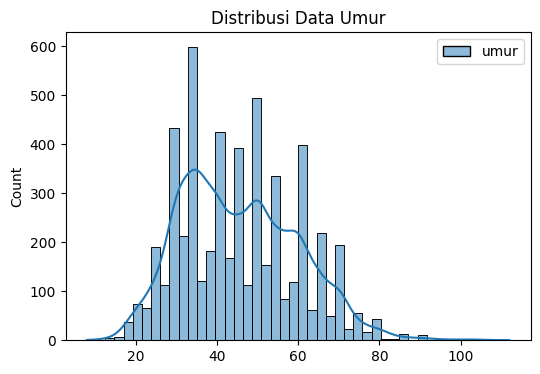

In [6]:
plot_distribution(pd.DataFrame(df['umur']))

In [7]:
df['umur'] = fill_missing_values(df['umur'], method='median')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [8]:
missing_value_insight(pd.DataFrame(df['jenis_kelamin']))

,Missing Values,Percentage
jenis_kelamin,0,0.0


In [9]:
uniqueGenderValuesCount = df['jenis_kelamin'].nunique()
uniqueGenderValues = np.array(df['jenis_kelamin'].unique())

print(f"Jumlah nilai unik pada kolom 'jenis_kelamin': {uniqueGenderValuesCount}")
print(f"Nilai unik pada kolom 'jenis_kelamin': {uniqueGenderValues}")

Jumlah nilai unik pada kolom 'jenis_kelamin': 2
Nilai unik pada kolom 'jenis_kelamin': ['Female' 'Male']


In [10]:
df['jenis_kelamin'] = fill_missing_values(df['jenis_kelamin'], method='mode')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [11]:
missing_value_insight(pd.DataFrame(df['pulse_rate']))

,Missing Values,Percentage
pulse_rate,0,0.0


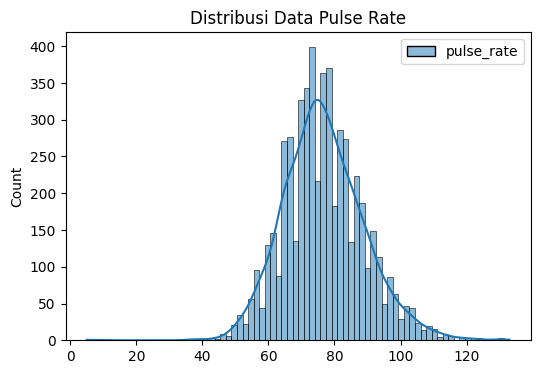

In [12]:
plot_distribution(pd.DataFrame(df['pulse_rate']))

In [13]:
df['pulse_rate'] = fill_missing_values(df['pulse_rate'], method='mean')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [14]:
missing_value_insight(pd.DataFrame(df['sistolik']))

,Missing Values,Percentage
sistolik,0,0.0


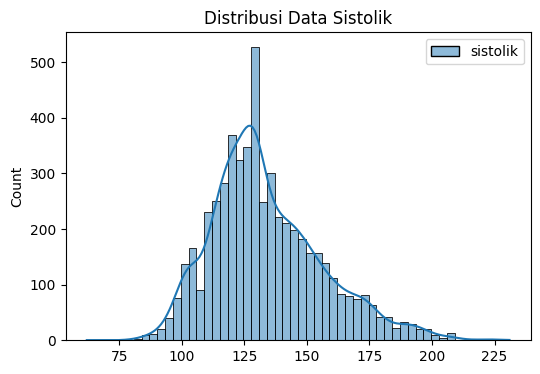

In [15]:
plot_distribution(pd.DataFrame(df['sistolik']))

In [16]:
df['sistolik'] = fill_missing_values(df['sistolik'], method='mean')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [17]:
missing_value_insight(pd.DataFrame(df['diastolik']))

,Missing Values,Percentage
diastolik,0,0.0


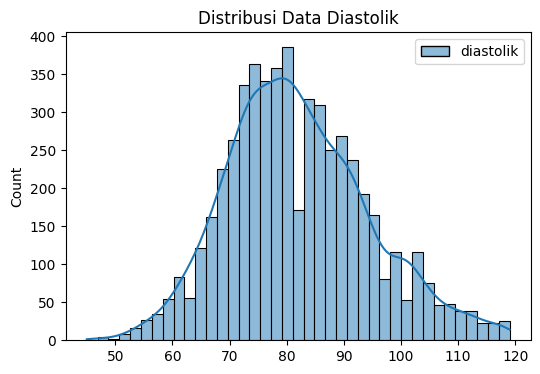

In [18]:
plot_distribution(pd.DataFrame(df['diastolik']))

In [19]:
df['diastolik'] = fill_missing_values(df['diastolik'], method='mean')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [20]:
missing_value_insight(pd.DataFrame(df['glukosa']))

,Missing Values,Percentage
glukosa,0,0.0


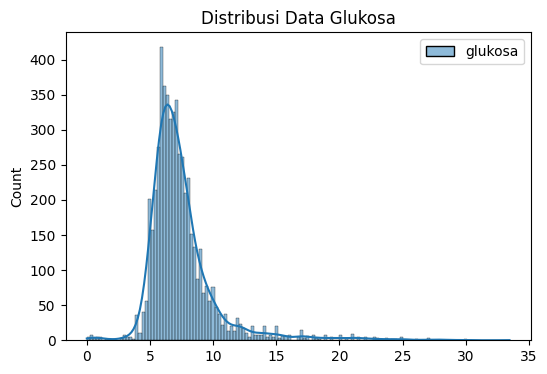

In [21]:
plot_distribution(pd.DataFrame(df['glukosa']))

In [22]:
df['glukosa'] = fill_missing_values(df['glukosa'], method='median')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [23]:
missing_value_insight(pd.DataFrame(df['height']))

,Missing Values,Percentage
height,0,0.0


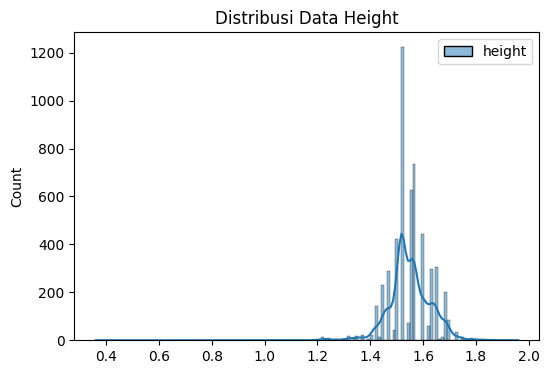

In [24]:
plot_distribution(pd.DataFrame(df['height']))

In [25]:
df['height'] = fill_missing_values(df['height'], method='mean')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [26]:
missing_value_insight(pd.DataFrame(df['weight']))

,Missing Values,Percentage
weight,0,0.0


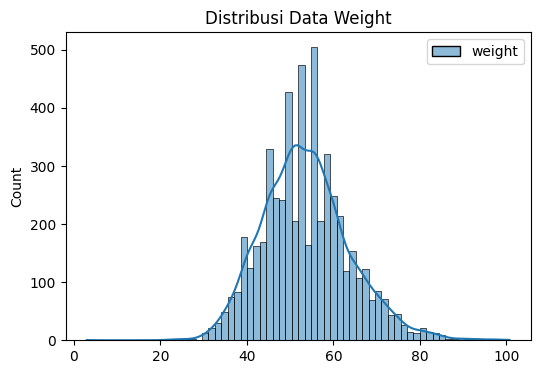

In [27]:
plot_distribution(pd.DataFrame(df['weight']))

In [28]:
df['weight'] = fill_missing_values(df['weight'], method='mean')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [29]:
missing_value_insight(pd.DataFrame(df['bmi']))

,Missing Values,Percentage
bmi,0,0.0


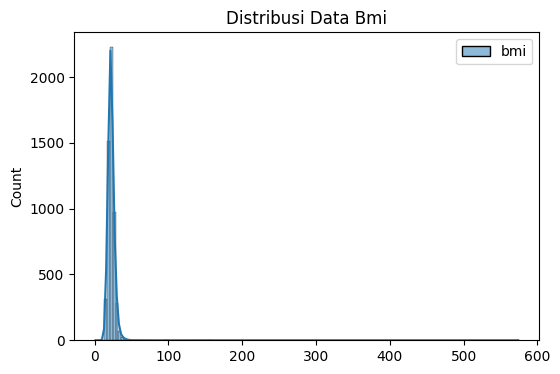

In [30]:
plot_distribution(pd.DataFrame(df['bmi']))

In [31]:
df['bmi'] = fill_missing_values(df['bmi'], method='mean')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [32]:
missing_value_insight(pd.DataFrame(df['family_diabetes']))

,Missing Values,Percentage
family_diabetes,0,0.0


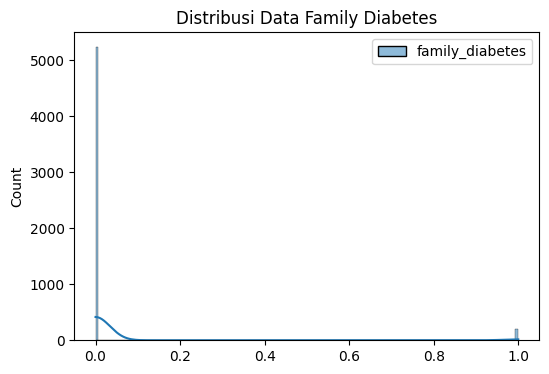

In [33]:
plot_distribution(pd.DataFrame(df['family_diabetes']))

In [34]:
df['family_diabetes'] = fill_missing_values(df['family_diabetes'], method='mode')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [35]:
missing_value_insight(pd.DataFrame(df['hypertensive']))

,Missing Values,Percentage
hypertensive,0,0.0


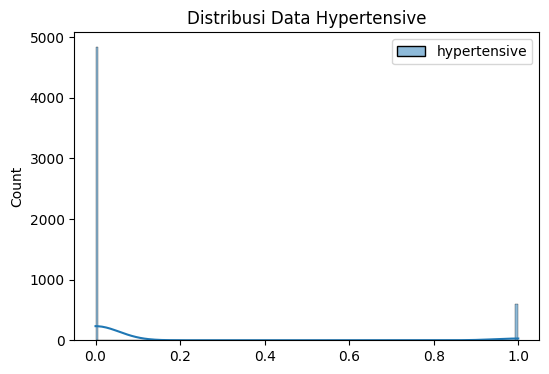

In [36]:
plot_distribution(pd.DataFrame(df['hypertensive']))

In [37]:
df['hypertensive'] = fill_missing_values(df['hypertensive'], method='mode')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [38]:
missing_value_insight(pd.DataFrame(df['family_hypertension']))

,Missing Values,Percentage
family_hypertension,0,0.0


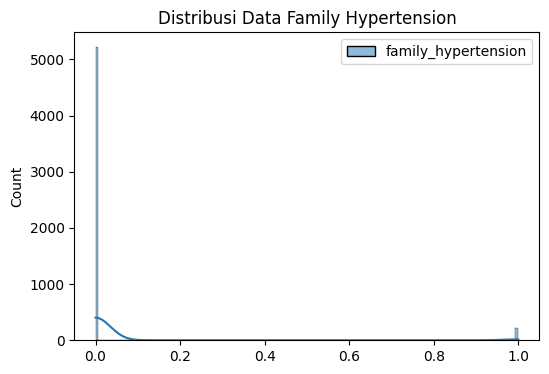

In [39]:
plot_distribution(pd.DataFrame(df['family_hypertension']))

In [40]:
df['family_hypertension'] = fill_missing_values(df['family_hypertension'], method='mode')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [41]:
missing_value_insight(pd.DataFrame(df['cardiovascular_disease']))

,Missing Values,Percentage
cardiovascular_disease,0,0.0


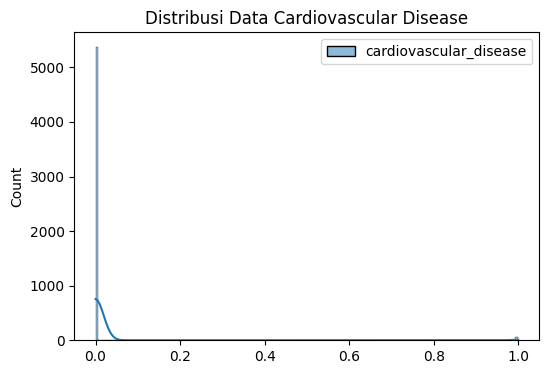

In [42]:
plot_distribution(pd.DataFrame(df['cardiovascular_disease']))

In [43]:
df['cardiovascular_disease'] = fill_missing_values(df['cardiovascular_disease'], method='mode')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [44]:
missing_value_insight(pd.DataFrame(df['stroke']))

,Missing Values,Percentage
stroke,0,0.0


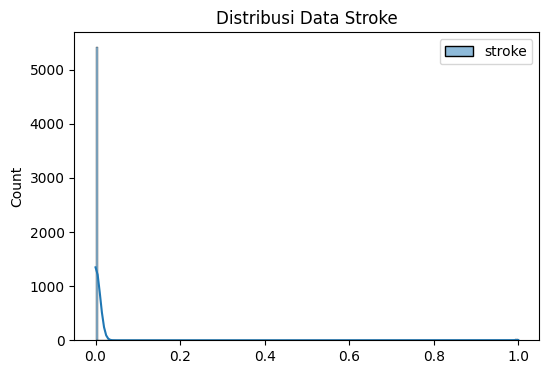

In [45]:
plot_distribution(pd.DataFrame(df['stroke']))

In [46]:
df['stroke'] = fill_missing_values(df['stroke'], method='mode')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No


In [47]:
# Normalisasi kolom family_hypertension
df['norm_family_hypertension'] = bulk_min_max_normalization(df['family_hypertension'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No,0.0
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No,0.0
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No,0.0
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No,0.0
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No,0.0
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes,0.0
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No,0.0
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No,0.0


In [48]:
# Normalisasi kolom cardiovascular_disease
df['norm_cardiovascular_disease'] = bulk_min_max_normalization(df['cardiovascular_disease'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No,0.0,0.0
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No,0.0,0.0
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No,0.0,0.0
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No,0.0,0.0
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No,0.0,1.0
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes,0.0,0.0
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No,0.0,0.0
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No,0.0,0.0


In [49]:
# Normalisasi kolom stroke
df['norm_stroke'] = bulk_min_max_normalization(df['stroke'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No,0.0,0.0,0.0
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No,0.0,0.0,0.0
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No,0.0,0.0,0.0
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No,0.0,0.0,0.0
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No,0.0,1.0,0.0
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes,0.0,0.0,0.0
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No,0.0,0.0,1.0
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No,0.0,0.0,0.0


Data Transformation

In [50]:
# Mapping Gender: Female to 1, Male to 0
df['transformed_gender'] = df['jenis_kelamin'].map(lambda e: 1 if e == 'Female' else 0)
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No,0.0,0.0,0.0,1
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No,0.0,0.0,0.0,1
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No,0.0,0.0,0.0,1
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No,0.0,0.0,0.0,0
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No,0.0,1.0,0.0,0
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes,0.0,0.0,0.0,0
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No,0.0,0.0,1.0,1
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No,0.0,0.0,0.0,1


In [51]:
uniqueDiagnoseValuesCount = df['diagnosa'].nunique()
uniqueDiagnoseValues = np.array(df['diagnosa'].unique())

print(f"Jumlah nilai unik pada kolom 'diagnosa': {uniqueDiagnoseValuesCount}")
print(f"Nilai unik pada kolom 'diagnosa': {uniqueDiagnoseValues}")

Jumlah nilai unik pada kolom 'diagnosa': 2
Nilai unik pada kolom 'diagnosa': ['No' 'Yes']


In [52]:
df['diagnosa'] = df['diagnosa'].map(lambda e: 1 if e == 'Yes' else 0)
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,0,0.0,0.0,0.0,1
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,0,0.0,0.0,0.0,1
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,0,0.0,0.0,0.0,1
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,0,0.0,0.0,0.0,0
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,0,0.0,1.0,0.0,0
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,1,0.0,0.0,0.0,0
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,0,0.0,0.0,1.0,1
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,0,0.0,0.0,0.0,1


In [53]:
# Normalisasi kolom Umur
df['norm_umur'] = bulk_min_max_normalization(df['umur'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,0,0.0,0.0,0.0,1,0.326923
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,0,0.0,0.0,0.0,1,0.259615
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,0,0.0,0.0,0.0,1,0.519231
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,0,0.0,0.0,0.0,0,0.625000
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,0,0.0,0.0,0.0,1,0.576923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,0,0.0,1.0,0.0,0,0.634615
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,1,0.0,0.0,0.0,0,0.644231
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,0,0.0,0.0,1.0,1,0.307692
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,0,0.0,0.0,0.0,1,0.269231


In [54]:
# Normalisasi kolom pulse_rate
df['norm_pulse_rate'] = bulk_min_max_normalization(df['pulse_rate'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,...,0,0,0,0,0.0,0.0,0.0,1,0.326923,0.476562
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,...,0,0,0,0,0.0,0.0,0.0,1,0.259615,0.429688
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,...,0,0,0,0,0.0,0.0,0.0,1,0.519231,0.406250
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,...,0,0,0,0,0.0,0.0,0.0,0,0.625000,0.390625
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,...,0,0,0,0,0.0,0.0,0.0,1,0.576923,0.515625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,...,0,1,0,0,0.0,1.0,0.0,0,0.634615,0.609375
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,...,0,0,0,1,0.0,0.0,0.0,0,0.644231,0.484375
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,...,0,0,1,0,0.0,0.0,1.0,1,0.307692,0.484375
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,...,0,0,0,0,0.0,0.0,0.0,1,0.269231,0.445312


In [55]:
# Normalisasi kolom sistolik
df['norm_sistolik'] = bulk_min_max_normalization(df['sistolik'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,...,0,0,0,0.0,0.0,0.0,1,0.326923,0.476562,0.284024
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,...,0,0,0,0.0,0.0,0.0,1,0.259615,0.429688,0.372781
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,...,0,0,0,0.0,0.0,0.0,1,0.519231,0.406250,0.384615
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,...,0,0,0,0.0,0.0,0.0,0,0.625000,0.390625,0.775148
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,...,0,0,0,0.0,0.0,0.0,1,0.576923,0.515625,0.520710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,...,1,0,0,0.0,1.0,0.0,0,0.634615,0.609375,0.603550
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,...,0,0,1,0.0,0.0,0.0,0,0.644231,0.484375,0.467456
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,...,0,1,0,0.0,0.0,1.0,1,0.307692,0.484375,0.426036
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,...,0,0,0,0.0,0.0,0.0,1,0.269231,0.445312,0.455621


In [56]:
# Normalisasi kolom diastolik
df['norm_diastolik'] = bulk_min_max_normalization(df['diastolik'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,...,0,0,0.0,0.0,0.0,1,0.326923,0.476562,0.284024,0.378378
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,...,0,0,0.0,0.0,0.0,1,0.259615,0.429688,0.372781,0.310811
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,...,0,0,0.0,0.0,0.0,1,0.519231,0.406250,0.384615,0.391892
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,...,0,0,0.0,0.0,0.0,0,0.625000,0.390625,0.775148,0.905405
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,...,0,0,0.0,0.0,0.0,1,0.576923,0.515625,0.520710,0.486486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,...,0,0,0.0,1.0,0.0,0,0.634615,0.609375,0.603550,0.594595
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,...,0,1,0.0,0.0,0.0,0,0.644231,0.484375,0.467456,0.797297
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,...,1,0,0.0,0.0,1.0,1,0.307692,0.484375,0.426036,0.932432
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,...,0,0,0.0,0.0,0.0,1,0.269231,0.445312,0.455621,0.472973


In [57]:
# Normalisasi kolom glukosa
df['norm_glukosa'] = bulk_min_max_normalization(df['glukosa'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,...,0,0.0,0.0,0.0,1,0.326923,0.476562,0.284024,0.378378,0.175732
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,...,0,0.0,0.0,0.0,1,0.259615,0.429688,0.372781,0.310811,0.170652
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,...,0,0.0,0.0,0.0,1,0.519231,0.406250,0.384615,0.391892,0.204722
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,...,0,0.0,0.0,0.0,0,0.625000,0.390625,0.775148,0.905405,0.187687
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,...,0,0.0,0.0,0.0,1,0.576923,0.515625,0.520710,0.486486,0.170652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,...,0,0.0,1.0,0.0,0,0.634615,0.609375,0.603550,0.594595,0.193365
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,...,1,0.0,0.0,0.0,0,0.644231,0.484375,0.467456,0.797297,0.248356
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,...,0,0.0,0.0,1.0,1,0.307692,0.484375,0.426036,0.932432,0.227436
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,...,0,0.0,0.0,0.0,1,0.269231,0.445312,0.455621,0.472973,0.146444


In [58]:
# Normalisasi kolom height
df['norm_height'] = bulk_min_max_normalization(df['height'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,...,0.0,0.0,0.0,1,0.326923,0.476562,0.284024,0.378378,0.175732,0.80625
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,...,0.0,0.0,0.0,1,0.259615,0.429688,0.372781,0.310811,0.170652,0.69375
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,...,0.0,0.0,0.0,1,0.519231,0.406250,0.384615,0.391892,0.204722,0.72500
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,...,0.0,0.0,0.0,0,0.625000,0.390625,0.775148,0.905405,0.187687,0.79375
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,...,0.0,0.0,0.0,1,0.576923,0.515625,0.520710,0.486486,0.170652,0.66250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,...,0.0,1.0,0.0,0,0.634615,0.609375,0.603550,0.594595,0.193365,0.77500
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,...,0.0,0.0,0.0,0,0.644231,0.484375,0.467456,0.797297,0.248356,0.80625
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,...,0.0,0.0,1.0,1,0.307692,0.484375,0.426036,0.932432,0.227436,0.71250
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,...,0.0,0.0,0.0,1,0.269231,0.445312,0.455621,0.472973,0.146444,0.72500


In [59]:
# Normalisasi kolom weight
df['norm_weight'] = bulk_min_max_normalization(df['weight'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,...,0.0,0.0,1,0.326923,0.476562,0.284024,0.378378,0.175732,0.80625,0.687820
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,...,0.0,0.0,1,0.259615,0.429688,0.372781,0.310811,0.170652,0.69375,0.404299
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,...,0.0,0.0,1,0.519231,0.406250,0.384615,0.391892,0.204722,0.72500,0.450358
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,...,0.0,0.0,0,0.625000,0.390625,0.775148,0.905405,0.187687,0.79375,0.556807
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,...,0.0,0.0,1,0.576923,0.515625,0.520710,0.486486,0.170652,0.66250,0.337769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,...,1.0,0.0,0,0.634615,0.609375,0.603550,0.594595,0.193365,0.77500,0.624360
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,...,0.0,0.0,0,0.644231,0.484375,0.467456,0.797297,0.248356,0.80625,0.603889
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,...,0.0,1.0,1,0.307692,0.484375,0.426036,0.932432,0.227436,0.71250,0.675537
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,...,0.0,0.0,1,0.269231,0.445312,0.455621,0.472973,0.146444,0.72500,0.394063


In [60]:
# Normalisasi kolom bmi
df['norm_bmi'] = bulk_min_max_normalization(df['bmi'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,...,0.0,1,0.326923,0.476562,0.284024,0.378378,0.175732,0.80625,0.687820,0.042816
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,...,0.0,1,0.259615,0.429688,0.372781,0.310811,0.170652,0.69375,0.404299,0.032047
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,...,0.0,1,0.519231,0.406250,0.384615,0.391892,0.204722,0.72500,0.450358,0.033199
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,...,0.0,0,0.625000,0.390625,0.775148,0.905405,0.187687,0.79375,0.556807,0.035782
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,...,0.0,1,0.576923,0.515625,0.520710,0.486486,0.170652,0.66250,0.337769,0.028923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,...,0.0,0,0.634615,0.609375,0.603550,0.594595,0.193365,0.77500,0.624360,0.041490
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,...,0.0,0,0.644231,0.484375,0.467456,0.797297,0.248356,0.80625,0.603889,0.037580
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,...,1.0,1,0.307692,0.484375,0.426036,0.932432,0.227436,0.71250,0.675537,0.051492
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,...,0.0,1,0.269231,0.445312,0.455621,0.472973,0.146444,0.72500,0.394063,0.029062


In [61]:
# Normalisasi kolom family_diabetes
df['norm_family_diabetes'] = bulk_min_max_normalization(df['family_diabetes'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,...,1,0.326923,0.476562,0.284024,0.378378,0.175732,0.80625,0.687820,0.042816,0.0
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,...,1,0.259615,0.429688,0.372781,0.310811,0.170652,0.69375,0.404299,0.032047,0.0
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,...,1,0.519231,0.406250,0.384615,0.391892,0.204722,0.72500,0.450358,0.033199,0.0
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,...,0,0.625000,0.390625,0.775148,0.905405,0.187687,0.79375,0.556807,0.035782,0.0
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,...,1,0.576923,0.515625,0.520710,0.486486,0.170652,0.66250,0.337769,0.028923,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,...,0,0.634615,0.609375,0.603550,0.594595,0.193365,0.77500,0.624360,0.041490,0.0
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,...,0,0.644231,0.484375,0.467456,0.797297,0.248356,0.80625,0.603889,0.037580,0.0
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,...,1,0.307692,0.484375,0.426036,0.932432,0.227436,0.71250,0.675537,0.051492,0.0
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,...,1,0.269231,0.445312,0.455621,0.472973,0.146444,0.72500,0.394063,0.029062,0.0


In [62]:
# Normalisasi kolom hypertensive
df['norm_hypertensive'] = bulk_min_max_normalization(df['hypertensive'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes,norm_hypertensive
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,...,0.326923,0.476562,0.284024,0.378378,0.175732,0.80625,0.687820,0.042816,0.0,0.0
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,...,0.259615,0.429688,0.372781,0.310811,0.170652,0.69375,0.404299,0.032047,0.0,0.0
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,...,0.519231,0.406250,0.384615,0.391892,0.204722,0.72500,0.450358,0.033199,0.0,0.0
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,...,0.625000,0.390625,0.775148,0.905405,0.187687,0.79375,0.556807,0.035782,0.0,0.0
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,...,0.576923,0.515625,0.520710,0.486486,0.170652,0.66250,0.337769,0.028923,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,...,0.634615,0.609375,0.603550,0.594595,0.193365,0.77500,0.624360,0.041490,0.0,1.0
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,...,0.644231,0.484375,0.467456,0.797297,0.248356,0.80625,0.603889,0.037580,0.0,0.0
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,...,0.307692,0.484375,0.426036,0.932432,0.227436,0.71250,0.675537,0.051492,0.0,1.0
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,...,0.269231,0.445312,0.455621,0.472973,0.146444,0.72500,0.394063,0.029062,0.0,0.0


In [63]:
# Normalisasi kolom family_hypertension
df['norm_family_hypertension'] = bulk_min_max_normalization(df['family_hypertension'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes,norm_hypertensive
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,...,0.326923,0.476562,0.284024,0.378378,0.175732,0.80625,0.687820,0.042816,0.0,0.0
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,...,0.259615,0.429688,0.372781,0.310811,0.170652,0.69375,0.404299,0.032047,0.0,0.0
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,...,0.519231,0.406250,0.384615,0.391892,0.204722,0.72500,0.450358,0.033199,0.0,0.0
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,...,0.625000,0.390625,0.775148,0.905405,0.187687,0.79375,0.556807,0.035782,0.0,0.0
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,...,0.576923,0.515625,0.520710,0.486486,0.170652,0.66250,0.337769,0.028923,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,...,0.634615,0.609375,0.603550,0.594595,0.193365,0.77500,0.624360,0.041490,0.0,1.0
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,...,0.644231,0.484375,0.467456,0.797297,0.248356,0.80625,0.603889,0.037580,0.0,0.0
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,...,0.307692,0.484375,0.426036,0.932432,0.227436,0.71250,0.675537,0.051492,0.0,1.0
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,...,0.269231,0.445312,0.455621,0.472973,0.146444,0.72500,0.394063,0.029062,0.0,0.0


In [64]:
# Normalisasi kolom cardiovascular_disease
df['norm_cardiovascular_disease'] = bulk_min_max_normalization(df['cardiovascular_disease'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes,norm_hypertensive
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,...,0.326923,0.476562,0.284024,0.378378,0.175732,0.80625,0.687820,0.042816,0.0,0.0
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,...,0.259615,0.429688,0.372781,0.310811,0.170652,0.69375,0.404299,0.032047,0.0,0.0
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,...,0.519231,0.406250,0.384615,0.391892,0.204722,0.72500,0.450358,0.033199,0.0,0.0
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,...,0.625000,0.390625,0.775148,0.905405,0.187687,0.79375,0.556807,0.035782,0.0,0.0
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,...,0.576923,0.515625,0.520710,0.486486,0.170652,0.66250,0.337769,0.028923,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,...,0.634615,0.609375,0.603550,0.594595,0.193365,0.77500,0.624360,0.041490,0.0,1.0
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,...,0.644231,0.484375,0.467456,0.797297,0.248356,0.80625,0.603889,0.037580,0.0,0.0
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,...,0.307692,0.484375,0.426036,0.932432,0.227436,0.71250,0.675537,0.051492,0.0,1.0
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,...,0.269231,0.445312,0.455621,0.472973,0.146444,0.72500,0.394063,0.029062,0.0,0.0


In [65]:
# Normalisasi kolom stroke
df['norm_stroke'] = bulk_min_max_normalization(df['stroke'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes,norm_hypertensive
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,...,0.326923,0.476562,0.284024,0.378378,0.175732,0.80625,0.687820,0.042816,0.0,0.0
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,...,0.259615,0.429688,0.372781,0.310811,0.170652,0.69375,0.404299,0.032047,0.0,0.0
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,...,0.519231,0.406250,0.384615,0.391892,0.204722,0.72500,0.450358,0.033199,0.0,0.0
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,...,0.625000,0.390625,0.775148,0.905405,0.187687,0.79375,0.556807,0.035782,0.0,0.0
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,...,0.576923,0.515625,0.520710,0.486486,0.170652,0.66250,0.337769,0.028923,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,...,0.634615,0.609375,0.603550,0.594595,0.193365,0.77500,0.624360,0.041490,0.0,1.0
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,...,0.644231,0.484375,0.467456,0.797297,0.248356,0.80625,0.603889,0.037580,0.0,0.0
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,...,0.307692,0.484375,0.426036,0.932432,0.227436,0.71250,0.675537,0.051492,0.0,1.0
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,...,0.269231,0.445312,0.455621,0.472973,0.146444,0.72500,0.394063,0.029062,0.0,0.0


In [66]:
df.to_csv("dataset_preprocessed.csv", index=False)

# Evaluasi Dataset
Mulai dari membaca csv yang sudah diekspor

In [67]:
readyDf = pd.read_csv("dataset_preprocessed.csv")[['transformed_gender', 'norm_umur', 'norm_pulse_rate', 'norm_sistolik', 'norm_diastolik', 'norm_glukosa', 'norm_height', 'norm_weight', 'norm_bmi', 'norm_family_diabetes', 'norm_hypertensive', 'norm_family_hypertension', 'norm_cardiovascular_disease', 'norm_stroke', 'diagnosa']]
readyDf

,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes,norm_hypertensive,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,diagnosa
0,1,0.326923,0.476562,0.284024,0.378378,0.175732,0.80625,0.687820,0.042816,0.0,0.0,0.0,0.0,0.0,0
1,1,0.259615,0.429688,0.372781,0.310811,0.170652,0.69375,0.404299,0.032047,0.0,0.0,0.0,0.0,0.0,0
2,1,0.519231,0.406250,0.384615,0.391892,0.204722,0.72500,0.450358,0.033199,0.0,0.0,0.0,0.0,0.0,0
3,0,0.625000,0.390625,0.775148,0.905405,0.187687,0.79375,0.556807,0.035782,0.0,0.0,0.0,0.0,0.0,0
4,1,0.576923,0.515625,0.520710,0.486486,0.170652,0.66250,0.337769,0.028923,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,0,0.634615,0.609375,0.603550,0.594595,0.193365,0.77500,0.624360,0.041490,0.0,1.0,0.0,1.0,0.0,0
5433,0,0.644231,0.484375,0.467456,0.797297,0.248356,0.80625,0.603889,0.037580,0.0,0.0,0.0,0.0,0.0,1
5434,1,0.307692,0.484375,0.426036,0.932432,0.227436,0.71250,0.675537,0.051492,0.0,1.0,0.0,0.0,1.0,0
5435,1,0.269231,0.445312,0.455621,0.472973,0.146444,0.72500,0.394063,0.029062,0.0,0.0,0.0,0.0,0.0,0


In [68]:
class DatasetEvaluator:
    def __init__(self, df: pd.DataFrame, training_size: float):
        self.df = df
        self.training_size = int(df.shape[0] * training_size)
    
    def split_datasets(self):
        # Memisahkan fitur (X) dan target (y)
        X = self.df[['norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_glukosa', 'transformed_gender']]
        y = self.df['diagnosa']

        # Membagi dataset menjadi data Latih (Train) dan data Uji (Test)
        self.X_train = X.iloc[:self.training_size]
        self.y_train = y.iloc[:self.training_size]
        self.X_test = X.iloc[self.training_size:]
        self.y_test = y.iloc[self.training_size:]

        print("Dimensi data latih - {},{}".format(self.X_train.shape, self.y_train.shape))
        print("Dimensi data validasi - {},{}".format(self.X_test.shape, self.y_test.shape))
        
    def evaluate_knn(self):
        # Iterate through different K values and distance metrics to evaluate performance
        for k_count in np.array([3, 5, 7, 9]):
            knn = KNN(k=k_count)
            knn.fit(self.X_train, self.y_train)

            predictions = knn.predict(self.X_test.values)
            y_pred = predictions['Euclidean']
            
            # for distance_type, y_pred in predictions.items(): -> uncomment this if want to use all distance types
            evaluator = MetricsEvaluator(y_pred, self.y_test.values)
            evaluator.plot_confusion_matrix(title=f"Confusion Matrix - Jarak Euclidean (K={k_count})")
            accuracy = evaluator.accuracy()
            precision = evaluator.precision()
            recall = evaluator.recall()
            f1_score = evaluator.f1_score()

            print(f"Results for Euclidean Distance (K={k_count})")
            print(f"Accuracy: {to_percent(accuracy)}, Precision: {to_percent(precision)}, Recall: {to_percent(recall)}, F1-Score: {to_percent(f1_score)}")
            print("-" * 80)

# Pembagian Data
Membagi dataset dengan komposisi train:test dengan beberapa skenario, di antaranya 80:20, 75:25, 90:10

# 80:20

Dimensi data latih - (4349, 5),(4349,)
Dimensi data validasi - (1088, 5),(1088,)
Results for Euclidean Distance (K=3)
Accuracy: 92.10%, Precision: 29.63%, Recall: 10.67%, F1-Score: 15.69%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 92.46%, Precision: 26.67%, Recall: 5.33%, F1-Score: 8.89%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 92.92%, Precision: 42.86%, Recall: 8.00%, F1-Score: 13.48%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 93.11%, Precision: 50.00%, Recall: 6.67%, F1-Score: 11.76%
--------------------------------------------------------------------------------


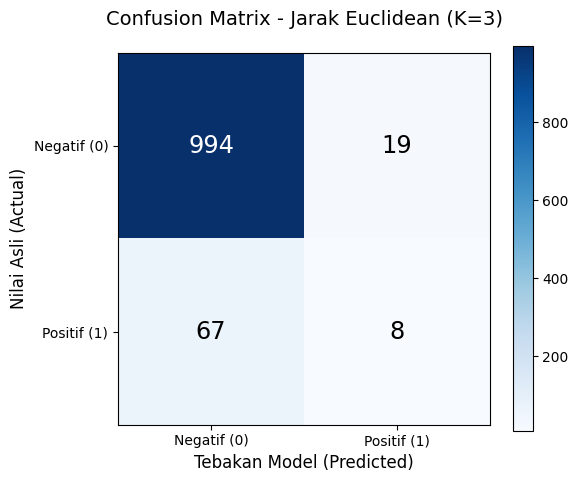

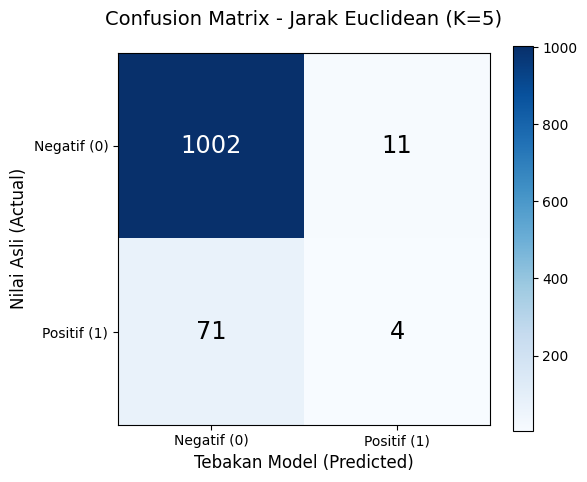

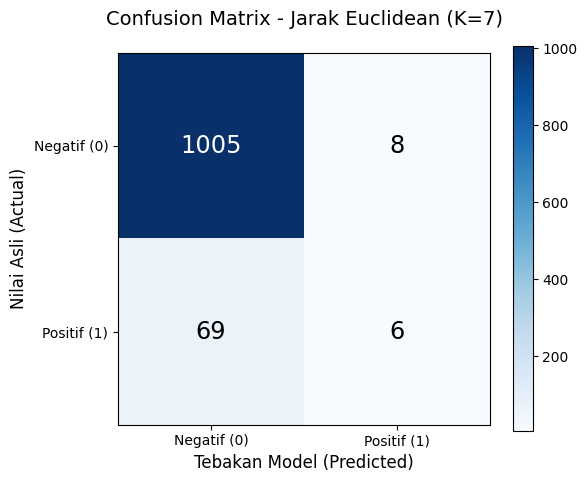

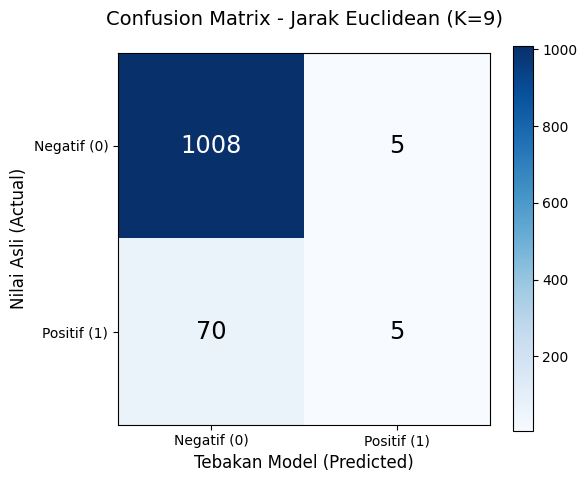

In [69]:
datasetEighty = DatasetEvaluator(readyDf, training_size=0.8)
datasetEighty.split_datasets()
datasetEighty.evaluate_knn()

# 75:25

Dimensi data latih - (4077, 5),(4077,)
Dimensi data validasi - (1360, 5),(1360,)
Results for Euclidean Distance (K=3)
Accuracy: 92.72%, Precision: 35.48%, Recall: 12.22%, F1-Score: 18.18%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 93.16%, Precision: 42.86%, Recall: 10.00%, F1-Score: 16.22%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 93.31%, Precision: 47.06%, Recall: 8.89%, F1-Score: 14.95%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 93.53%, Precision: 57.14%, Recall: 8.89%, F1-Score: 15.38%
--------------------------------------------------------------------------------


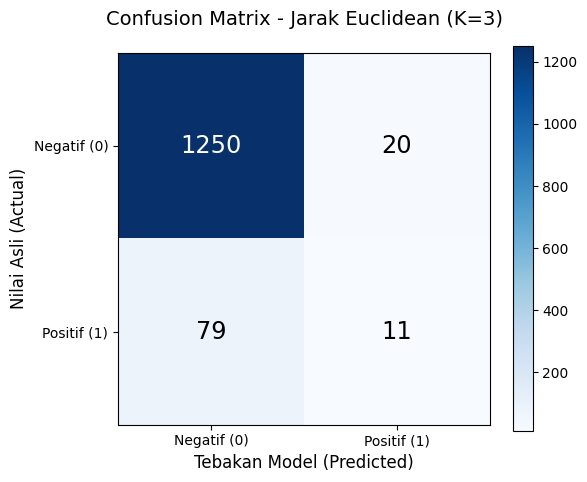

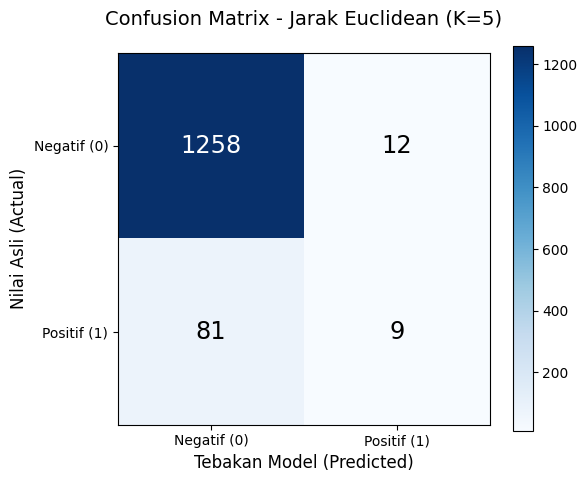

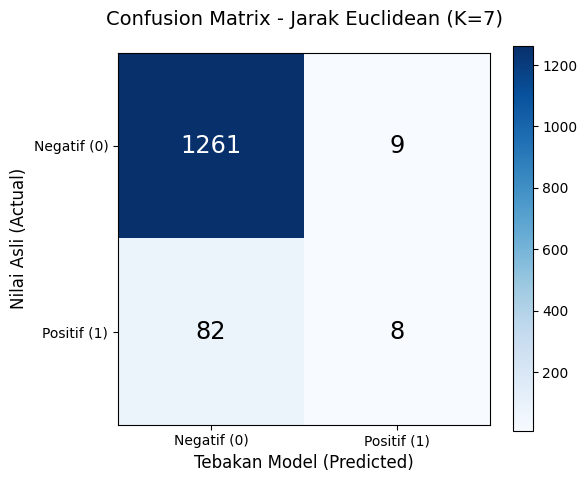

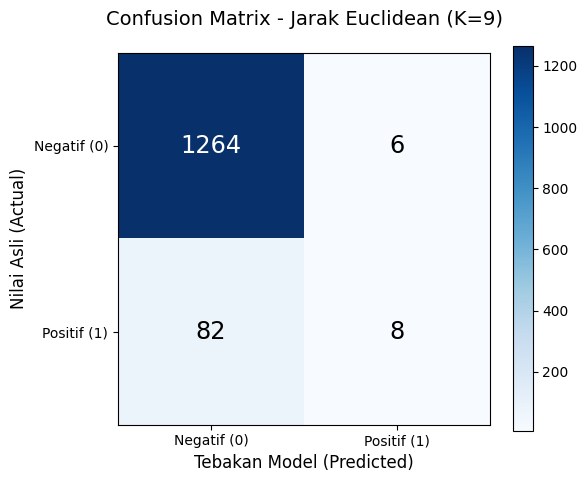

In [70]:
datasetSeventyFive = DatasetEvaluator(readyDf, training_size=0.75)
datasetSeventyFive.split_datasets()
datasetSeventyFive.evaluate_knn()

# 90:10

Dimensi data latih - (4893, 5),(4893,)
Dimensi data validasi - (544, 5),(544,)
Results for Euclidean Distance (K=3)
Accuracy: 91.73%, Precision: 20.00%, Recall: 5.13%, F1-Score: 8.16%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 92.10%, Precision: 16.67%, Recall: 2.56%, F1-Score: 4.44%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 92.46%, Precision: 25.00%, Recall: 2.56%, F1-Score: 4.65%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 92.28%, Precision: 20.00%, Recall: 2.56%, F1-Score: 4.55%
--------------------------------------------------------------------------------


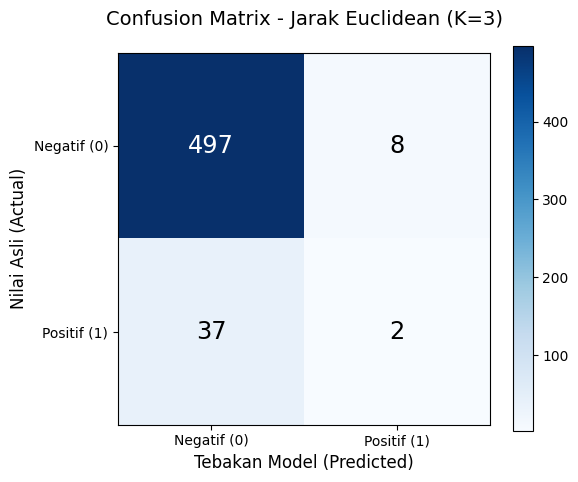

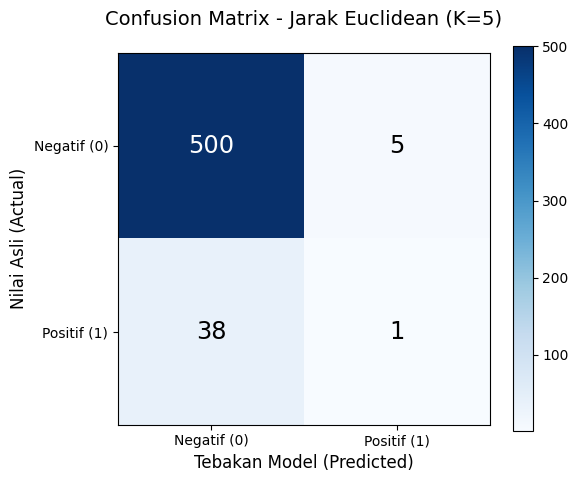

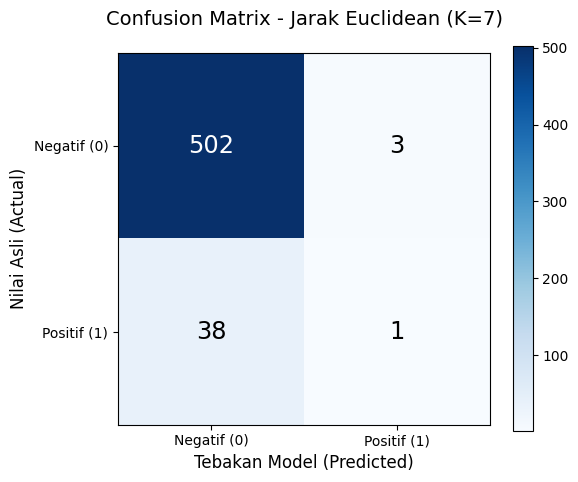

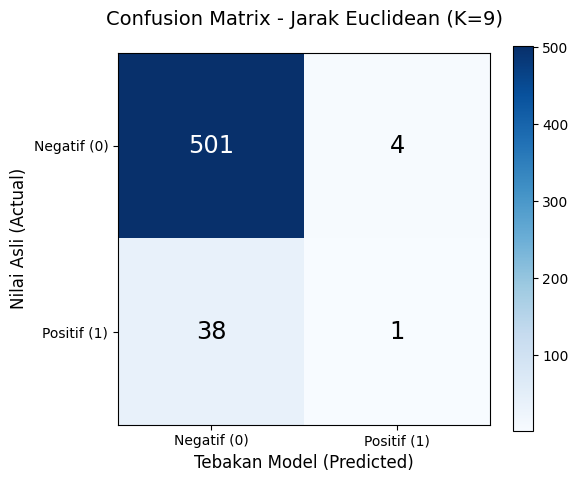

In [71]:
datasetNinety = DatasetEvaluator(readyDf, training_size=0.9)
datasetNinety.split_datasets()
datasetNinety.evaluate_knn()

# K-Fold Cross Validation => K = 4, 5, 10

In [72]:
K = np.array([4, 5, 10])

In [73]:
kFoldDf = pd.read_csv("dataset_preprocessed.csv")[['transformed_gender', 'norm_umur', 'norm_pulse_rate', 'norm_sistolik', 'norm_diastolik', 'norm_glukosa', 'norm_height', 'norm_weight', 'norm_bmi', 'norm_family_diabetes', 'norm_hypertensive', 'norm_family_hypertension', 'norm_cardiovascular_disease', 'norm_stroke', 'diagnosa']]
kFoldDf

,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes,norm_hypertensive,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,diagnosa
0,1,0.326923,0.476562,0.284024,0.378378,0.175732,0.80625,0.687820,0.042816,0.0,0.0,0.0,0.0,0.0,0
1,1,0.259615,0.429688,0.372781,0.310811,0.170652,0.69375,0.404299,0.032047,0.0,0.0,0.0,0.0,0.0,0
2,1,0.519231,0.406250,0.384615,0.391892,0.204722,0.72500,0.450358,0.033199,0.0,0.0,0.0,0.0,0.0,0
3,0,0.625000,0.390625,0.775148,0.905405,0.187687,0.79375,0.556807,0.035782,0.0,0.0,0.0,0.0,0.0,0
4,1,0.576923,0.515625,0.520710,0.486486,0.170652,0.66250,0.337769,0.028923,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5432,0,0.634615,0.609375,0.603550,0.594595,0.193365,0.77500,0.624360,0.041490,0.0,1.0,0.0,1.0,0.0,0
5433,0,0.644231,0.484375,0.467456,0.797297,0.248356,0.80625,0.603889,0.037580,0.0,0.0,0.0,0.0,0.0,1
5434,1,0.307692,0.484375,0.426036,0.932432,0.227436,0.71250,0.675537,0.051492,0.0,1.0,0.0,0.0,1.0,0
5435,1,0.269231,0.445312,0.455621,0.472973,0.146444,0.72500,0.394063,0.029062,0.0,0.0,0.0,0.0,0.0,0


In [74]:
X = kFoldDf[['transformed_gender', 'norm_umur', 'norm_pulse_rate', 'norm_sistolik', 'norm_diastolik', 'norm_glukosa', 'norm_height', 'norm_weight', 'norm_bmi', 'norm_family_diabetes', 'norm_hypertensive', 'norm_family_hypertension', 'norm_cardiovascular_disease', 'norm_stroke']]
y = kFoldDf['diagnosa']

In [75]:
from sklearn.model_selection import StratifiedKFold

results_storage = []

for k_count in K:
    # Buat objek Stratified K-Fold
    skf = StratifiedKFold(n_splits=k_count, shuffle=True, random_state=42)
    
    for fold_index, (train_idx, test_idx) in enumerate(list(skf.split(X,y))):
        k_X_train, k_X_test = X.iloc[train_idx], X.iloc[test_idx]
        k_y_train, k_y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        for k_knn in np.array([3, 5, 7, 9]):
            print(f"Fold {fold_index + 1}/{k_count} - K={k_knn}")
            knn = KNN(k=k_knn)
            knn.fit(k_X_train, k_y_train)

            predictions = knn.predict(k_X_test.values)
            y_pred = predictions['Euclidean']
            
            evaluator = MetricsEvaluator(y_pred, k_y_test.values)
            
            results_storage.append({
                'K_Fold': k_count,
                'Fold': fold_index + 1,
                'K_KNN': k_knn,
                'Distance': 'Euclidean',
                'Accuracy': evaluator.accuracy(),
                'Precision': evaluator.precision(),
                'Recall': evaluator.recall(),
                'F1_Score': evaluator.f1_score()
            })

Fold 1/4 - K=3
Fold 1/4 - K=5
Fold 1/4 - K=7
Fold 1/4 - K=9
Fold 2/4 - K=3
Fold 2/4 - K=5
Fold 2/4 - K=7
Fold 2/4 - K=9
Fold 3/4 - K=3
Fold 3/4 - K=5
Fold 3/4 - K=7
Fold 3/4 - K=9
Fold 4/4 - K=3
Fold 4/4 - K=5
Fold 4/4 - K=7
Fold 4/4 - K=9
Fold 1/5 - K=3
Fold 1/5 - K=5
Fold 1/5 - K=7
Fold 1/5 - K=9
Fold 2/5 - K=3
Fold 2/5 - K=5
Fold 2/5 - K=7
Fold 2/5 - K=9
Fold 3/5 - K=3
Fold 3/5 - K=5
Fold 3/5 - K=7
Fold 3/5 - K=9
Fold 4/5 - K=3
Fold 4/5 - K=5
Fold 4/5 - K=7
Fold 4/5 - K=9
Fold 5/5 - K=3
Fold 5/5 - K=5
Fold 5/5 - K=7
Fold 5/5 - K=9
Fold 1/10 - K=3
Fold 1/10 - K=5
Fold 1/10 - K=7
Fold 1/10 - K=9
Fold 2/10 - K=3
Fold 2/10 - K=5
Fold 2/10 - K=7
Fold 2/10 - K=9
Fold 3/10 - K=3
Fold 3/10 - K=5
Fold 3/10 - K=7
Fold 3/10 - K=9
Fold 4/10 - K=3
Fold 4/10 - K=5
Fold 4/10 - K=7
Fold 4/10 - K=9
Fold 5/10 - K=3
Fold 5/10 - K=5
Fold 5/10 - K=7
Fold 5/10 - K=9
Fold 6/10 - K=3
Fold 6/10 - K=5
Fold 6/10 - K=7
Fold 6/10 - K=9
Fold 7/10 - K=3
Fold 7/10 - K=5
Fold 7/10 - K=7
Fold 7/10 - K=9
Fold 8/10 - 

In [76]:
df_results = pd.DataFrame(results_storage)
df_results

,K_Fold,Fold,K_KNN,Distance,Accuracy,Precision,Recall,F1_Score
0,4,1,3,Euclidean,0.936029,0.487179,0.220930,0.304000
1,4,1,5,Euclidean,0.937500,0.513514,0.220930,0.308943
2,4,1,7,Euclidean,0.939706,0.583333,0.162791,0.254545
3,4,1,9,Euclidean,0.944118,0.750000,0.174419,0.283019
4,4,2,3,Euclidean,0.925681,0.368421,0.244186,0.293706
...,...,...,...,...,...,...,...,...
71,10,9,9,Euclidean,0.941068,0.583333,0.205882,0.304348
72,10,10,3,Euclidean,0.928177,0.380952,0.235294,0.290909
73,10,10,5,Euclidean,0.933702,0.437500,0.205882,0.280000
74,10,10,7,Euclidean,0.942910,0.615385,0.235294,0.340426


In [77]:
sorted_df_results = df_results.sort_values(by=['F1_Score'], ascending=False).reset_index(drop=True)
sorted_df_results

,K_Fold,Fold,K_KNN,Distance,Accuracy,Precision,Recall,F1_Score
0,10,6,3,Euclidean,0.946691,0.650000,0.371429,0.472727
1,5,3,3,Euclidean,0.943882,0.600000,0.308824,0.407767
2,10,2,5,Euclidean,0.948529,0.750000,0.264706,0.391304
3,10,2,7,Euclidean,0.948529,0.750000,0.264706,0.391304
4,10,3,5,Euclidean,0.939338,0.526316,0.294118,0.377358
...,...,...,...,...,...,...,...,...
71,10,7,3,Euclidean,0.930147,0.363636,0.114286,0.173913
72,5,4,9,Euclidean,0.939282,0.666667,0.086957,0.153846
73,5,4,7,Euclidean,0.936523,0.500000,0.072464,0.126582
74,10,8,9,Euclidean,0.937385,0.500000,0.058824,0.105263


In [78]:
best_configs = sorted_df_results.iloc[0:2][['K_Fold', 'Fold', 'K_KNN']]
best_configs

,K_Fold,Fold,K_KNN
0,10,6,3
1,5,3,3


Fold 6/10 - K=3
Fold 3/5 - K=3


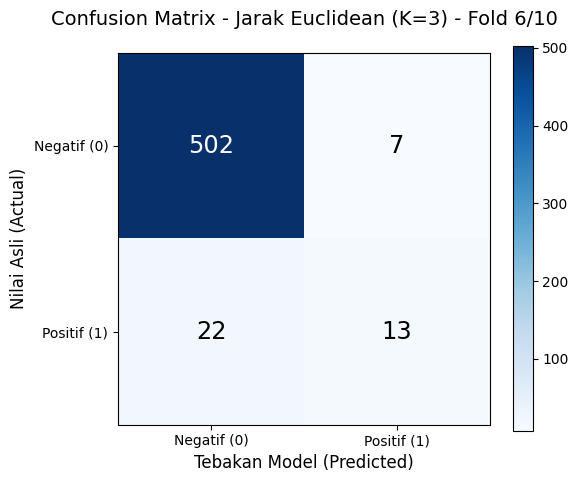

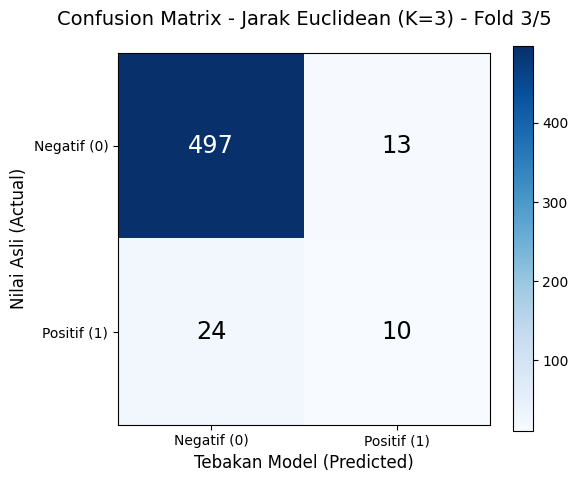

In [79]:
import joblib

skf = StratifiedKFold(n_splits=k_count, shuffle=True, random_state=42)

for best_config in best_configs.itertuples(index=False):
    for k_count in np.array([best_config.K_Fold]): # K-Fold Cross Validation
        for fold_index, (train_idx, test_idx) in enumerate(list(skf.split(X,y))):
            if(fold_index != best_config.Fold - 1): continue # nth Fold, -1 because index starts from 0
            
            best_X_train, best_X_test = X.iloc[train_idx], X.iloc[test_idx]
            best_y_train, best_y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            for k_knn in np.array([best_config.K_KNN]): # K KNN
                print(f"Fold {fold_index + 1}/{k_count} - K={k_knn}")
                knn = KNN(k=k_knn)
                knn.fit(best_X_train, best_y_train)
                knn.dump(best_X_test, best_y_test)  # Save the test data for later use
                joblib.dump(knn, "best_knn_model.joblib")

                predictions = knn.predict(best_X_test.values)
                best_y_pred = predictions['Euclidean']
                
                evaluator = MetricsEvaluator(best_y_pred, best_y_test.values)
                evaluator.plot_confusion_matrix(
                    title=f"Confusion Matrix - Jarak Euclidean (K={k_knn}) - Fold {fold_index + 1}/{k_count}"
                )

In [80]:
summary_results = df_results.groupby(['K_Fold', 'K_KNN'])[['Accuracy', 'Precision', 'Recall', 'F1_Score']].agg(['mean']).reset_index()
summary_results.columns = ['_'.join(col).strip('_') for col in summary_results.columns.values]
summary_results

,K_Fold,K_KNN,Accuracy_mean,Precision_mean,Recall_mean,F1_Score_mean
0,4,3,0.932683,0.447661,0.229651,0.301946
1,4,5,0.935810,0.489582,0.197674,0.279558
2,4,7,0.939673,0.582592,0.171512,0.263714
3,4,9,0.942615,0.700877,0.162791,0.264163
4,5,3,0.934523,0.474106,0.241475,0.316735
5,5,5,0.938935,0.551230,0.215132,0.306784
6,5,7,0.940040,0.586269,0.171526,0.261654
7,5,9,0.943351,0.727435,0.171569,0.274217
8,10,3,0.931948,0.430155,0.223866,0.289560
9,10,5,0.938751,0.545667,0.209496,0.299990


In [81]:
sorted_kfold = summary_results.sort_values(by='F1_Score_mean', ascending=False)

print(f"K-Fold      : {sorted_kfold.iloc[0]['K_Fold']}")
print(f"K-KNN       : {sorted_kfold.iloc[0]['K_KNN']}")
print(f"Accuracy    : {to_percent(sorted_kfold.iloc[0]['Accuracy_mean'])}")
print(f"Precision   : {to_percent(sorted_kfold.iloc[0]['Precision_mean'])}")
print(f"Recall      : {to_percent(sorted_kfold.iloc[0]['Recall_mean'])}")
print(f"F1-Score    : {to_percent(sorted_kfold.iloc[0]['F1_Score_mean'])}")

K-Fold      : 5.0
K-KNN       : 3.0
Accuracy    : 93.45%
Precision   : 47.41%
Recall      : 24.15%
F1-Score    : 31.67%


In [82]:
# Grouping berdasarkan K_Fold dan K_KNN, lalu hitung rata-rata dari semua fold untuk setiap kombinasi K_Fold dan K_KNN
df_avg_double_k = df_results.groupby(['K_Fold', 'K_KNN'])[['Accuracy', 'Precision', 'Recall', 'F1_Score']].mean().reset_index()
df_avg_double_k

,K_Fold,K_KNN,Accuracy,Precision,Recall,F1_Score
0,4,3,0.932683,0.447661,0.229651,0.301946
1,4,5,0.935810,0.489582,0.197674,0.279558
2,4,7,0.939673,0.582592,0.171512,0.263714
3,4,9,0.942615,0.700877,0.162791,0.264163
4,5,3,0.934523,0.474106,0.241475,0.316735
5,5,5,0.938935,0.551230,0.215132,0.306784
6,5,7,0.940040,0.586269,0.171526,0.261654
7,5,9,0.943351,0.727435,0.171569,0.274217
8,10,3,0.931948,0.430155,0.223866,0.289560
9,10,5,0.938751,0.545667,0.209496,0.299990
